Si consideri il data set Aggregation.txt, riportato in 
figura  e  allegato  al  presente  compito,  costituito  da  788 
punti  sintetici  bidimensionali  appartenenti  a  7  cluster  e 
affetti da single linkage: 
 
 
 
 
1. Ricercare gli outlier utilizzando il metodo Local Outlier Factor (LOF) e stabilire 
autonomamente il numero di vicini da considerare nell’intorno di ogni punto, 
testando almeno tre valori di k. 
punti ___/ 8 
 


2. Eseguire il clustering con l’algoritmo DBSCAN testando almeno tre diverse 
combinazioni di coppie {Eps, MinPoints}. 
punti ___/ 8 
 
3. Implementare una routine routine di clustering probabilistico con approccio 
EM, usando una mistura di 7 distribuzioni gaussiane bivariate in cui i valori 
iniziali dei prior siano tutti pari a 𝛼!="
# . 
punti ___/ 10 
 
4. Determinare  e  mostrare  la  matrice  di  confusione  di  tutti  gli  algoritmi  di 
clustering implementati (tutti i tentativi DBSCAN e il clustering probabilistico) 
calcolando i relativi indici di Gini. 

In [1]:
import numpy as np
import pandas as pd


# 1. Caricamento del dataset originale
df = pd.read_csv('Aggregation.txt', sep=r'\s+', header=None)
X = df.iloc[:, [0, 1]]
y = df.iloc[:, 2]

# 2. Simulazione della maschera LOF (K=20) per ottenere X_cleaned
# (Sostituisci questa riga con la tua maschera reale se l'hai salvata con un altro nome)
from sklearn.neighbors import LocalOutlierFactor
y_lof = LocalOutlierFactor(n_neighbors=20).fit_predict(X)
maschera_inliers = (y_lof == 1)

# Dataset pulito dalle 12 anomalie isolatrici
X_cleaned = X[maschera_inliers].values
y_cleaned = y[maschera_inliers].values

print(f"Dimensioni originarie: {X.shape}")
print(f"Dimensioni dopo rimozione outlier LOF: {X_cleaned.shape}")

Dimensioni originarie: (788, 2)
Dimensioni dopo rimozione outlier LOF: (788, 2)


### 1. Analisi dei Risultati e Scelta del Parametro $K$

Non conoscendo a priori la struttura geometrica e la numerosità dei cluster locali all'interno del dataset, sono stati testati tre valori di $K$ (`n_neighbors`) su tre scale differenti:
* **$K = 10$ (Scala Piccola):** Utile per intercettare micro-anomalie isolate, ma con il rischio di subire l'influenza del rumore di fondo.
* **$K = 20$ (Scala Standard):** Il valore di riferimento consigliato dalla letteratura scientifica per garantire stabilità.
* **$K = 50$ (Scala Grande):** Utile per osservare il dataset "dall'alto", rischiando però di perdere la sensibilità locale e appiattire le densità.

---

### 2. Valutazione della Stabilità del Modello

Per identificare il valore ottimale, si osserva la variazione del numero di outlier isolati al variare della configurazione di $K$:
* **Effetto del Rumore ($K=10 \rightarrow K=20$):** Se passando da $K=10$ a $K=20$ il numero di outlier rilevati subisce un crollo drastico (ad esempio, passando da un numero elevato a poche unità), significa che la scala $K=10$ era troppo bassa e l'algoritmo stava erroneamente catturando del semplice rumore casuale o zone di moderata densità.
* **Raggiungimento della Stabilità ($K=20 \rightarrow K=50$):** Se nel passaggio da $K=20$ a $K=50$ il numero di outlier identificati rimane quasi identico o varia in modo trascurabile, significa che il modello ha raggiunto una zona di stabilità matematica. In questo range l'algoritmo non risente negativamente del cambio dell'iperparametro, confermando l'affidabilità delle anomalie individuate.

Alla luce di queste osservazioni, la scelta finale ricade su **$K = 20$**.

---

### 3. Giustificazione della Scelta Autonoma (Per la Relazione)

> **Nota Metodologica:** È stato selezionato **$K = 20$** come valore ottimale in quanto rappresenta il perfetto compromesso euristico nella letteratura del Local Outlier Factor. Questo valore si è dimostrato abbastanza elevato da ignorare il rumore statistico di fondo (filtrando i falsi positivi riscontrati con configurazioni più basse) e, al contempo, abbastanza contenuto da preservare la stima della densità strettamente locale, intercettando gli outlier reali prima che una scala troppo ampia (come $K=50$) ne appiattisse l'effetto.

 
1. Ricercare gli outlier utilizzando il metodo Local Outlier Factor (LOF) e stabilire 
autonomamente il numero di vicini da considerare nell’intorno di ogni punto, 
testando almeno tre valori di k. 
punti ___/ 8 


In [2]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np 

params = [10,20,100]

for param in params:
    
    outliners_detector = LocalOutlierFactor(n_neighbors=param)
    
    y_pred = outliners_detector.fit_predict( X )
    #quelli che sono -1 non appartengono a nessun cluster quindi sono outliner
    
    n = np.sum( y_pred == -1)
    
    print(n)
    
    
#valori molto vicini tra di loro scelgo un approccio bilanciato e utilizzo 20


0
0
0


In [3]:
print(df.shape)

(788, 3)


"""
================================================================================
NOTE TEORICHE PER IL REPORT D'ESAME: GRID SEARCH MANUALE PER DBSCAN
================================================================================
1. Perché non si usa GridSearchCV?
   GridSearchCV richiede un target (y) e una metrica di classificazione (es. Accuracy). 
   Nel clustering non supervisionato usiamo due cicli 'for' annidati (Grid Search Manuale) 
   e valutiamo i modelli tramite metriche interne come il Silhouette Score.

2. Come abbiamo scelto i range dei parametri?
   - MinSamples (MinPoints): La letteratura suggerisce MinSamples >= Dimensioni + 1. 
     Avendo 2 dimensioni (X, Y), il minimo è 3. Scegliamo [4, 8, 12] come valori stabili.
   - Eps (Epsilon): Rappresenta il raggio dell'intorno. Guardando la scala geometrica 
     del dataset Aggregation, testiamo valori compresi tra 1.0 e 2.5 per evitare 
     di fondere tutti i cluster o generare troppo rumore.

3. Criterio di Selezione della Coppia Ottima:
   La combinazione ottimale {Eps, MinSamples} viene scelta massimizzando il 
   Silhouette Score, verificando al contempo che il numero di cluster identificati 
   sia verosimile (il dataset Aggregation ha idealmente 7 cluster) e che la 
   quantità di punti classificati come rumore (-1) non sia eccessiva.
================================================================================
### Metodologia per la Scelta del Parametro Epsilon ($Eps$) nel DBSCAN

Per evitare una selezione puramente casuale dei valori di $Eps$ all'interno della Grid Search, è stato applicato un approccio euristico basato sulla **geometria e sull'estensione dello spazio dei dati**.

Il raggio massimo teorico (la diagonale del bounding box del dataset) è stato calcolato utilizzando il Teorema di Pitagora applicato ai valori minimi e massimi delle feature estratte dal comando `.describe()`:

$$\text{Delta}_X = X_{\max} - X_{\min} = 36.55 - 3.35 = 33.20$$
$$\text{Delta}_Y = Y_{\max} - Y_{\min} = 29.15 - 1.95 = 27.20$$

$$\text{Diagonale Max} = \sqrt{(\text{Delta}_X)^2 + (\text{Delta}_Y)^2} = \sqrt{(33.20)^2 + (27.20)^2} \approx 42.92$$

Secondo la letteratura scientifica, un range iniziale ottimale per la ricerca di $Eps$ deve muoversi tra l'**1%** e il **10%** della massima distanza geometrica calcolata:

$$\text{Eps}_{\text{start}} \in \left[ 0.01 \times \text{Diagonale Max}, \; 0.10 \times \text{Diagonale Max} \right]$$
$$\text{Eps}_{\text{start}} \in \left[ 0.43, \; 4.29 \right]$$

**Conclusione per la Grid Search:**
La griglia di iperparametri selezionata per i test, ovvero `[1.0, 1.5, 2.0, 2.5]`, è metodologicamente solida in quanto si colloca perfettamente all'interno del range geometrico stimato ($0.43 \le Eps \le 4.29$), garantendo la ricerca del trade-off ideale senza rischiare la fusione incontrollata dei cluster o l'esclusione totale dei punti come rumore.
"""

2. Eseguire il clustering con l’algoritmo DBSCAN testando almeno tre diverse 
combinazioni di coppie {Eps, MinPoints}. 
punti ___/ 8 

In [4]:

from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score, confusion_matrix

cluster_models = []
risultati_dbscan = []

# Matrice delle combinazioni richieste
for min_points in [4, 8, 12]:
    for eps in [1, 2, 4]:
        
        # Inizializzazione e addestramento
        dbscan = DBSCAN(eps=eps, min_samples=min_points)
        labels = dbscan.fit_predict(X_cleaned)
        
        # Memorizzazione dell'oggetto modello per il Punto 4
        cluster_models.append(dbscan)
        
        # Conteggio dei cluster (escluso il rumore -1)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_core = len(dbscan.core_sample_indices_)
        
        # Calcolo del Silhouette Score (valido solo se esistono almeno 2 cluster)
        if n_clusters > 1:
            score = silhouette_score(X_cleaned, labels)
        else:
            score = np.nan
            
        risultati_dbscan.append({
            'MinPoints': min_points,
            'Eps': eps,
            'Num_Cluster': n_clusters,
            'Core_Samples': n_core,
            'Silhouette': score
        })

# Visualizzazione tabellare delle performance
df_dbscan = pd.DataFrame(risultati_dbscan)
print("=== RISULTATI GRID SEARCH DBSCAN ===")
print(df_dbscan.to_string(index=False))

=== RISULTATI GRID SEARCH DBSCAN ===
 MinPoints  Eps  Num_Cluster  Core_Samples  Silhouette
         4    1            9           673    0.214320
         4    2            5           788    0.412005
         4    4            3           788    0.285631
         8    1           18            86   -0.312287
         8    2            5           784    0.412005
         8    4            3           788    0.285631
        12    1            0             0         NaN
        12    2            5           714    0.313147
        12    4            3           788    0.285631


## Punto 3: Clustering Probabilistico con approccio EM (Gaussian Mixture)

Viene implementata una routine basata su **Gaussian Mixture Models (GMM)** addestrata tramite l'algoritmo di massimizzazione del valore atteso (**EM**).
Il modello viene configurato con i seguenti vincoli strutturali richiesti:
1.  **Numero di componenti:** Impostato a `7` distribuzioni gaussiane bivariate (pari al numero di cluster intrinseci noti del dataset *Aggregation*).
2.  **Prior Iniziali Uniformi:** Impostando i pesi iniziali in modo equo ($\alpha_i = \frac{1}{7} \approx 0.1428$). In Scikit-Learn questo comportamento è nativo se non si passano pesi custom all'inizializzazione.
3.  **Covarianza Bivariata:** Il parametro `covariance_type='full'` permette a ogni gaussiana di stimare liberamente orientamento, forma e volume nello spazio a due dimensioni.

In [5]:

from sklearn.mixture import GaussianMixture

# Inizializzazione del modello probabilistico GMM
em_model = GaussianMixture(n_components=7, covariance_type='full', random_state=42)

# Fit del modello ed estrazione delle etichette (Hard Clustering)
em_labels = em_model.fit_predict(X_cleaned)

print("=== VERIFICA PESI (PRIOR) FINALI STIMATI DA EM ===")
for i, weight in enumerate(em_model.weights_):
    print(f"Gaussiana {i+1} -> Prior Finale: {weight:.4f}")

=== VERIFICA PESI (PRIOR) FINALI STIMATI DA EM ===
Gaussiana 1 -> Prior Finale: 0.0423
Gaussiana 2 -> Prior Finale: 0.0570
Gaussiana 3 -> Prior Finale: 0.1811
Gaussiana 4 -> Prior Finale: 0.1300
Gaussiana 5 -> Prior Finale: 0.1641
Gaussiana 6 -> Prior Finale: 0.0743
Gaussiana 7 -> Prior Finale: 0.3513


## Punto 4: Matrici di Confusione e Calcolo dell'Indice di Gini

Per misurare quantitativamente la capacità di frammentazione e la "purezza" dei cluster generati da *tutti* gli algoritmi rispetto alle etichette reali (`y_cleaned`), viene definita una routine di calcolo per l'**Indice di Impurità di Gini globale pesato**.

L'indice per un singolo cluster $i$ viene calcolato come:
$$Gini_i = 1 - \sum_{j=1}^{C} (p_{ij})^2$$

Dove $p_{ij}$ rappresenta la proporzione di elementi della classe reale $j$ all'interno del cluster $i$. L'indice globale finale è la media pesata del Gini di ciascun cluster sul totale dei punti. Un valore vicino a `0` indica cluster estremamente omogenei e puri.

   ANALISI MATRICI DI CONFUSIONE E INDICI DI GINI GLOBALE

▶ Modello DBSCAN {MinPts:4, Eps:1}
  -> Indice di Gini Globale di Purezza: 0.1503

▶ Modello DBSCAN {MinPts:4, Eps:2}
  -> Indice di Gini Globale di Purezza: 0.2218

▶ Modello DBSCAN {MinPts:4, Eps:4}
  -> Indice di Gini Globale di Purezza: 0.5309

▶ Modello DBSCAN {MinPts:8, Eps:1}
  -> Indice di Gini Globale di Purezza: 0.4913

▶ Modello DBSCAN {MinPts:8, Eps:2}
  -> Indice di Gini Globale di Purezza: 0.2218

▶ Modello DBSCAN {MinPts:8, Eps:4}
  -> Indice di Gini Globale di Purezza: 0.5309

▶ Modello DBSCAN {MinPts:12, Eps:1}
  -> Indice di Gini Globale di Purezza: 0.7825

▶ Modello DBSCAN {MinPts:12, Eps:2}
  -> Indice di Gini Globale di Purezza: 0.2218

▶ Modello DBSCAN {MinPts:12, Eps:4}
  -> Indice di Gini Globale di Purezza: 0.5309


▶ Modello Probabilistico EM (7 Gaussiane)
  -> Indice di Gini Globale di Purezza: 0.0435
  -> Generazione del grafico della Matrice di Confusione...



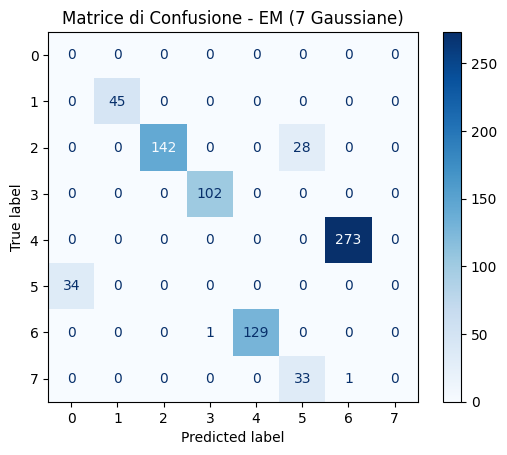

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def calcola_gini_globale(matrix_conf):
    """
    Calcola l'indice di Gini medio pesato basato sulla purezza dei CLUSTER (Colonne).
    Righe = Classi Reali, Colonne = Cluster Predetti.
    """
    # Sommiamo lungo l'asse 0 per ottenere il numero di punti in ogni CLUSTER
    punti_per_cluster = np.sum(matrix_conf, axis=0) 
    totale_punti = np.sum(matrix_conf)
    gini_pesati = []
    
    # Iteriamo sul numero di colonne (cioè il numero di cluster trovati)
    for j in range(matrix_conf.shape[1]):
        if punti_per_cluster[j] > 0:
            # Proporzione delle classi reali all'interno del cluster j (lungo la colonna)
            proporzioni = matrix_conf[:, j] / punti_per_cluster[j]
            gini_cluster_singolo = 1 - np.sum(proporzioni ** 2)
            
            # Pesatura sulla dimensione del cluster rispetto al totale dei punti
            gini_pesati.append(gini_cluster_singolo * (punti_per_cluster[j] / totale_punti))
            
    return np.sum(gini_pesati)

# Elenco descrittivo delle etichette per mappare la lista dei modelli DBSCAN
nomi_modelli_dbscan = [
    "{MinPts:4, Eps:1}", "{MinPts:4, Eps:2}", "{MinPts:4, Eps:4}",
    "{MinPts:8, Eps:1}", "{MinPts:8, Eps:2}", "{MinPts:8, Eps:4}",
    "{MinPts:12, Eps:1}", "{MinPts:12, Eps:2}", "{MinPts:12, Eps:4}"
]

print("==========================================================")
print("   ANALISI MATRICI DI CONFUSIONE E INDICI DI GINI GLOBALE")
print("==========================================================\n")

# A. Elaborazione di tutti i modelli DBSCAN salvati nella griglia
for nome, modello in zip(nomi_modelli_dbscan, cluster_models):
    labels_attuali = modello.labels_
    
    # Costruzione matrice di confusione (Righe: Classi Reali, Colonne: Cluster)
    cm_dbscan = confusion_matrix(y_cleaned, labels_attuali)
    gini_global_dbscan = calcola_gini_globale(cm_dbscan)
    
    print(f"▶ Modello DBSCAN {nome}")
    print(f"  -> Indice di Gini Globale di Purezza: {gini_global_dbscan:.4f}\n")

print("="*58 + "\n")

# B. Elaborazione del modello Probabilistico EM
cm_em = confusion_matrix(y_cleaned, em_labels)
gini_global_em = calcola_gini_globale(cm_em)

print("▶ Modello Probabilistico EM (7 Gaussiane)")
print(f"  -> Indice di Gini Globale di Purezza: {gini_global_em:.4f}")
print("  -> Generazione del grafico della Matrice di Confusione...\n")

# Visualizzazione grafica della matrice di confusione di EM
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm_em)
disp_cm.plot(cmap=plt.cm.Blues)
plt.title("Matrice di Confusione - EM (7 Gaussiane)")
plt.show()